#### This notebook shows how to read the CMRxRecon dataset and apply some simple transformations to the data.
#### We utilized some useful codes from fastMRI repo.

In [1]:
%matplotlib inline
%matplotlib widget

import h5py
import numpy as np
from matplotlib import pyplot as plt
import hdf5storage


The CMRxRecon dataset is distributed as a set of HDF5 files and can be read with the h5py package. Here, we first show how to open a file from the multi-coil dataset. Each file corresponds to ntime * nslice of MRI scan and contains the k-space data.

In [2]:
file_name = 'data/raw/cmrxrecon/ChallengeData/MultiCoil/Cine/TrainingSet/FullSample/P001/cine_sax.mat'
hf_m = h5py.File(file_name)

In [3]:
def load_and_prepare(file_name):
    hf_m = h5py.File(file_name)
    newvalue = hf_m[list(hf_m.keys())[0]]
    fullmulti = newvalue["real"] + 1j*newvalue["imag"]
    return fullmulti

In [16]:
acc4_fullmulti = load_and_prepare('data/raw/cmrxrecon/ChallengeData/MultiCoil/Cine/TrainingSet/AccFactor04/P001/cine_sax.mat')

In [5]:
acc8_fullmulti = load_and_prepare('data/raw/cmrxrecon/ChallengeData/MultiCoil/Cine/TrainingSet/AccFactor08/P001/cine_sax.mat')

In [6]:
acc10_fullmulti = load_and_prepare('data/raw/cmrxrecon/ChallengeData/MultiCoil/Cine/TrainingSet/AccFactor10/P001/cine_sax.mat')

In [17]:
# here to load the kspace data
newvalue = hf_m['kspace_full']
fullmulti = newvalue["real"] + 1j*newvalue["imag"]

In [18]:
[nframe, nslice, ncoil, ny, nx] = fullmulti.shape
print(nframe, nslice, ncoil, ny, nx, acc4_fullmulti.shape)

12 10 10 204 512 (12, 10, 10, 204, 512)


In multi-coil MRIs, k-space has the following shape: 

#number of frame, number of slices, number of coils, ny, nx (ny is the phase encoding direction for undersampling)

For single-coil MRIs, k-space has the following shape: #number of frame, number of slices, ny, nx


In [19]:
# choose the first frame and the middle slice
slice_kspace = fullmulti[0,5] 

Let's see what the absolute value of k-space looks like:

In [20]:
def show_coils(data, slice_nums, cmap=None, vmax = 0.0005):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap,vmax=vmax)

In [21]:
(((acc10_fullmulti == 0).sum(axis=(-2,-1))//512)==162).min(), acc8_fullmulti.shape

(True, (12, 10, 10, 204, 512))

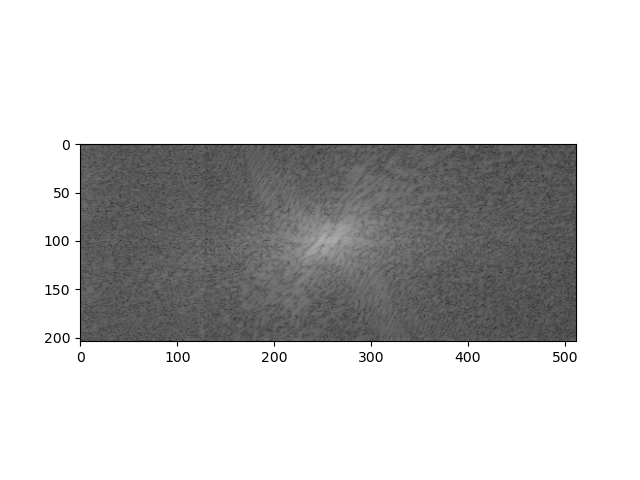

In [22]:
show_coils(np.log(np.abs(slice_kspace) + 1e-9), [0], cmap='gray', vmax = 0.0001)  # This shows coils 0, 5 and 9
# show_coils(np.abs(slice_kspace) - np.abs(acc4_fullmulti[0,5]), [0], cmap='gray', vmax = 0.0001)  # This shows coils 0, 5 and 9
# show_coils(np.log(np.abs(acc4_fullmulti[0,5]) + 1e-9), [0, 4, 9], cmap='gray', vmax = 0.0001)  # This shows coils 0, 5 and 9
# show_coils(np.log(np.abs(acc8_fullmulti[0,5]) + 1e-9), [0, 4, 9], cmap='gray', vmax = 0.0001)  # This shows coils 0, 5 and 9
# show_coils(np.log(np.abs(acc4_fullmulti[0,5]) + 1e-9), [0], cmap='gray', vmax = 0.0001)  # This shows coils 0, 5 and 9

In [23]:
from src.vis_utils import create_animation_general
imgs_to_animate = np.log(np.abs(acc4_fullmulti[:,0,0]) + 1e-9)
# im1 = np.concatenate([imgs_to_animate[:,i] for i in range(0, imgs_to_animate.shape[1], 2)], axis=1)
# im2 = np.concatenate([imgs_to_animate[:,i] for i in range(1, imgs_to_animate.shape[1], 2)], axis=1)
# imgs_to_animate = np.concatenate([im1, im2], axis=2)
# imgs_to_animate = np.concatenate([imgs_to_animate[:,i] for i in range(imgs_to_animate.shape[1])], axis=1)
print(imgs_to_animate.shape)
html, ani = create_animation_general(imgs_to_animate, cmap='gray')

(12, 204, 512)


We acknowledged fastMRI repo for their utlity functions to convert k-space into image space. These functions work on PyTorch Tensors. The to_tensor function can convert Numpy arrays to PyTorch Tensors.

In [24]:
import fastmri
from fastmri.data import transforms as T

In [51]:
singcoil_fullmulti = load_and_prepare('data/raw/cmrxrecon/ChallengeData/SingleCoil/Cine/TrainingSet/FullSample/P001/cine_sax.mat')
middle_sing_coil = singcoil_fullmulti[:,0]

In [52]:
sing_coil_t = T.to_tensor(middle_sing_coil)
sing_coil_image = fastmri.ifft2c(sing_coil_t)
sing_coil_image_abs = fastmri.complex_abs(sing_coil_image)
sing_coil_t.shape, sing_coil_image.shape, sing_coil_image_abs.shape

(torch.Size([12, 204, 512, 2]),
 torch.Size([12, 204, 512, 2]),
 torch.Size([12, 204, 512]))

In [53]:
im_html, _ = create_animation_general(sing_coil_image_abs, cmap="gray")

In [54]:
im_html

In [31]:
singcoil_fullmulti.shape # time, slice, h, w

(12, 3, 204, 448)

In [32]:
slice_kspace2 = T.to_tensor(slice_kspace)              # Convert from numpy array to pytorch tensor
slice_image = fastmri.ifft2c(slice_kspace2)           # Apply Inverse Fourier Transform to get the complex image
slice_image_abs = fastmri.complex_abs(slice_image)   # Compute absolute value to get a real image

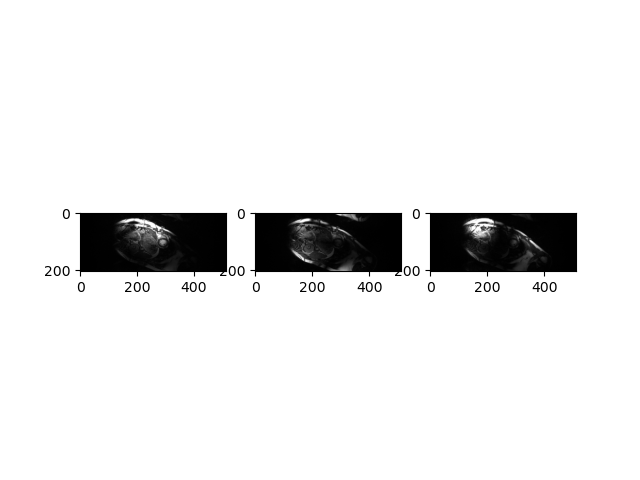

In [35]:
show_coils(slice_image_abs, [0, 3, 6], cmap='gray', vmax = 0.0005)

As we can see, each coil in a multi-coil MRI scan focusses on a different region of the image. These coils can be combined into the full image using the Root-Sum-of-Squares (RSS) transform.

In [36]:
slice_image_rss = fastmri.rss(slice_image_abs, dim=0)

In [37]:
plt.imshow(np.abs(slice_image_rss.numpy()), cmap='gray', vmax = 0.0015)

So far, we have been looking at fully-sampled multi-coil data. We can also apply the similar operator to the undersampled single-coil data to see how it can be changed to image domain.

In [38]:
file_name = 'data/raw/cmrxrecon/ChallengeData/SingleCoil/Cine/TrainingSet/AccFactor04/P001/cine_sax.mat'
hf_s = h5py.File(file_name)

In [39]:
print('Keys:', list(hf_s.keys()))

Keys: ['kspace_single_sub04']


In [40]:
# here to load the kspace data, the keys are differnt for different acceleration factors
newvalue_s = hf_s['kspace_single_sub04']
undersinglesample = newvalue_s["real"] + 1j*newvalue_s["imag"]
underslice = undersinglesample[0,5] # Choosing the middle slice of this volume

In [41]:
underslice.shape

(204, 512)

In [42]:
plt.imshow(np.abs(underslice), cmap='gray', vmax = 0.001)

Let's see what the subsampled image looks like:

In [43]:
underslice2 = T.to_tensor(underslice)              # Convert from numpy array to pytorch tensor
sampled_image = fastmri.ifft2c(underslice2)           # Apply Inverse Fourier Transform to get the complex image
sampled_image_abs = fastmri.complex_abs(sampled_image)   # Compute absolute value to get a real image
#sampled_image_rss = fastmri.rss(sampled_image_abs, dim=0)

In [44]:
sampled_image_abs.shape

torch.Size([204, 512])

In [46]:
plt.imshow(np.abs(sampled_image_abs.numpy()), cmap='gray',vmax = 0.0015)

Here we try to save the numpy to mat73 file, please use hdf5storage function. 
For a large numpy array, it may take a longer time (e.g. up to two minutes for a multi-coil file). 

In [22]:
def savenumpy2mat(data, np_var, filepath):
    ''' 
    np_var: str, the name of the variable in the mat file.
    data: numpy, array to save.
    filepath: str, the path to save the mat file.
    '''
    savedict= {}
    savedict[np_var] = data
    hdf5storage.savemat(filepath, savedict)


In [23]:
savenumpy2mat(underslice, 'underkspace', 'underkslice.mat')